In [2]:
### EDA Road Map ####
## Data sanity check
## Univariate analysis
## Bivariate analysis (with target)
## Feature relationships (multivariate thinking)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/MyDrive/insurance.csv")

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# New section

1. Data Sanity Check

In [7]:
df.shape

(986, 15)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 986 entries, 0 to 985
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      986 non-null    int64  
 1   Diabetes                 986 non-null    int64  
 2   BloodPressureProblems    986 non-null    int64  
 3   AnyTransplants           986 non-null    int64  
 4   AnyChronicDiseases       986 non-null    int64  
 5   Height                   986 non-null    int64  
 6   Weight                   986 non-null    int64  
 7   KnownAllergies           986 non-null    int64  
 8   HistoryOfCancerInFamily  986 non-null    int64  
 9   NumberOfMajorSurgeries   986 non-null    int64  
 10  PremiumPrice             986 non-null    int64  
 11  Clean BMI Formula        986 non-null    float64
 12  BMI Categories           986 non-null    object 
 13  Risk Category            986 non-null    object 
 14  Health Score             9

In [9]:
df.isnull().sum()

,0
Age,0
Diabetes,0
BloodPressureProblems,0
AnyTransplants,0
AnyChronicDiseases,0
Height,0
Weight,0
KnownAllergies,0
HistoryOfCancerInFamily,0
NumberOfMajorSurgeries,0


In [10]:
df["PremiumPrice"].describe()

,PremiumPrice
count,986.000000
mean,24336.713996
std,6248.184382
min,15000.000000
25%,21000.000000
50%,23000.000000
75%,28000.000000
max,40000.000000


<Axes: xlabel='PremiumPrice', ylabel='Count'>

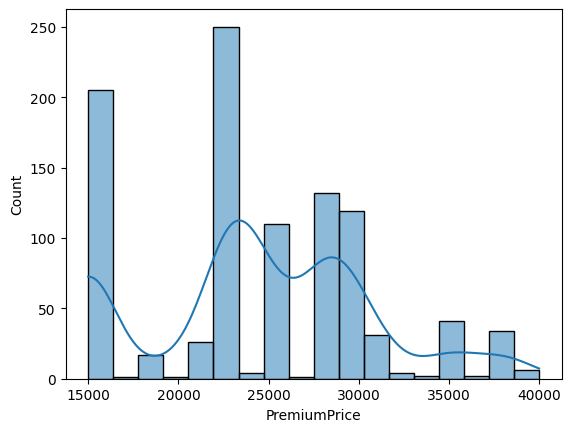

In [11]:
sns.histplot(df["PremiumPrice"], kde=True)

### Few Insights
## “Premium distribution is right-skewed”
## “Most customers fall between 20K–35K”
## “Few high-cost outliers exist (~40K)”

In [12]:
## Key Numerical Features
# Age
# BMI
# Number of Surgeries
# Weight/Height

<Axes: xlabel='Age', ylabel='Count'>

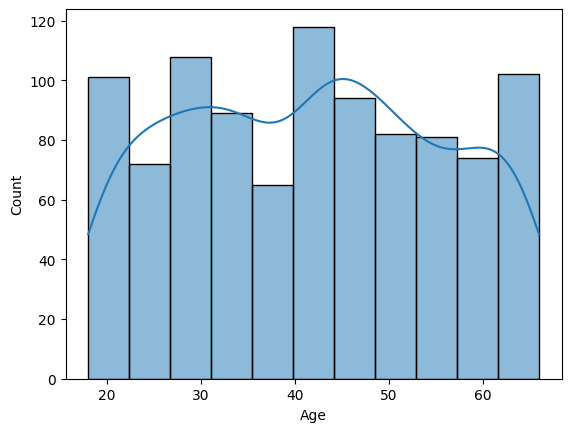

In [13]:
sns.histplot(df['Age'], kde=True)

In [14]:
df["NumberOfMajorSurgeries"].value_counts()

,count
NumberOfMajorSurgeries,
0,479
1,372
2,119
3,16


## “Majority have 0–1 surgeries”

In [15]:
## Categorical Variables
# Risk Category
# BMI Category

In [16]:
df['Risk Category'].value_counts()

,count
Risk Category,
Medium Risk,448
High Risk,322
Low Risk,216


In [17]:
df['BMI Categories'].value_counts()

,count
BMI Categories,
Overweight,325
Normal,319
Obese,303
Underweight,39


## Bi-Variate Anlysis

## Age vs Premium

<Axes: xlabel='Age', ylabel='PremiumPrice'>

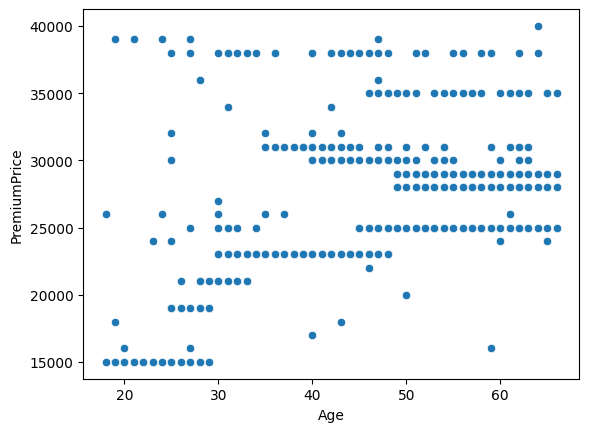

In [18]:
sns.scatterplot(x='Age',y='PremiumPrice', data=df)

<Axes: xlabel='Age', ylabel='PremiumPrice'>

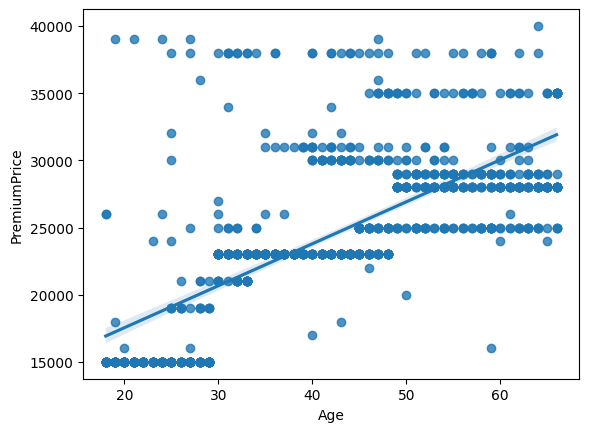

In [19]:
sns.regplot(x='Age', y='PremiumPrice', data=df)

In [20]:
## Trend
# “Premium increases with age (moderate positive correlation)”

<Axes: xlabel='BMI Categories', ylabel='PremiumPrice'>

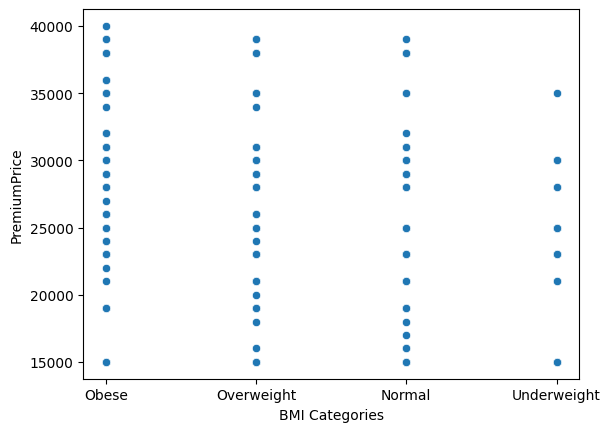

In [21]:
sns.scatterplot(x='BMI Categories', y='PremiumPrice', data=df)

<Axes: xlabel='NumberOfMajorSurgeries', ylabel='PremiumPrice'>

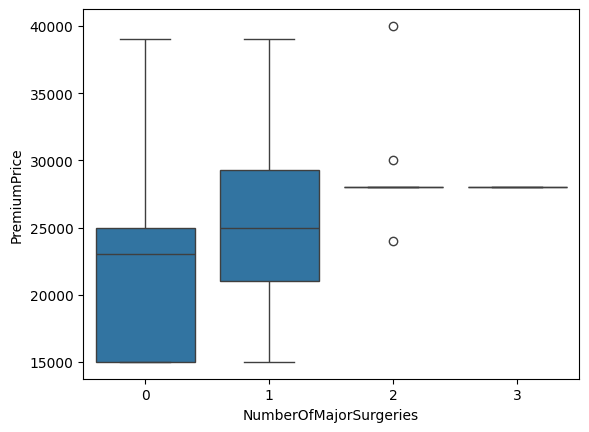

In [22]:
sns.boxplot(x='NumberOfMajorSurgeries', y='PremiumPrice', data=df)

<Axes: xlabel='Diabetes', ylabel='PremiumPrice'>

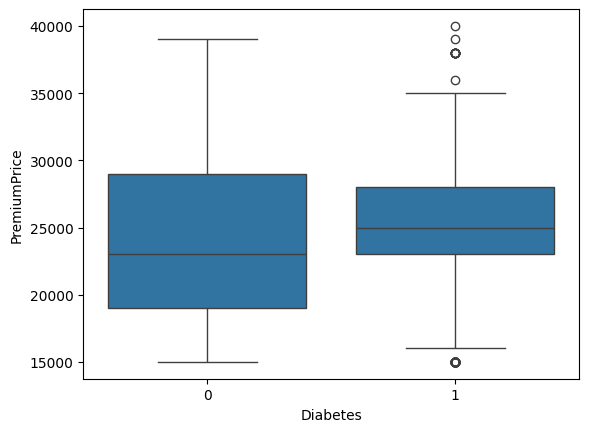

In [23]:
sns.boxplot(x='Diabetes', y='PremiumPrice', data=df)

<Axes: >

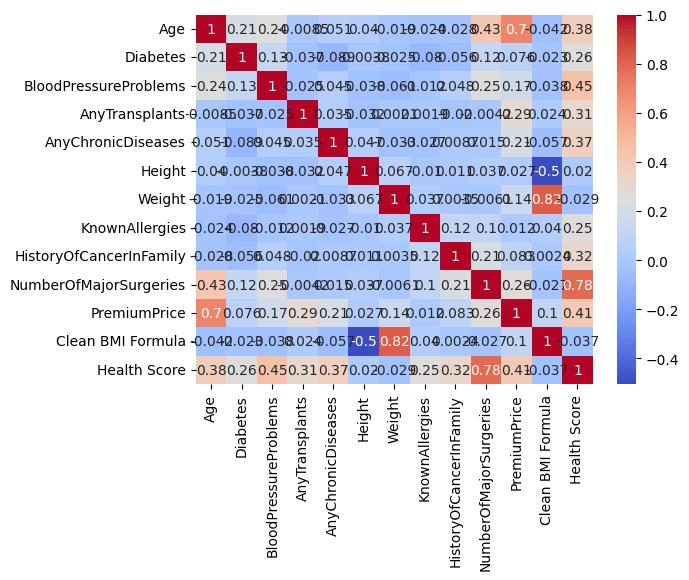

In [24]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')

# Age is the dominant predictor of premium pricing
# Medical conditions such as surgeries and chronic diseases significantly #increase premiums
#BMI provides more predictive power than raw height/weight
#Several features exhibit multicollinearity and require feature selection or #regularization
#Premium variability increases with risk factors, indicating non-linear #relationships

## Hypothesis testing

In [25]:
from scipy.stats import ttest_ind

# Surgery test
no_surgery = df[df['NumberOfMajorSurgeries'] == 0]['PremiumPrice']
surgery = df[df['NumberOfMajorSurgeries'] >= 1]['PremiumPrice']

ttest_ind(no_surgery, surgery)

TtestResult(statistic=np.float64(-6.835938237389611), pvalue=np.float64(1.427444450490173e-11), df=np.float64(984.0))

In [26]:
no_diabetes = df[df['Diabetes'] == 0]['PremiumPrice']
diabetes = df[df['Diabetes'] == 1]['PremiumPrice']

ttest_ind(no_diabetes, diabetes)

TtestResult(statistic=np.float64(-2.3975629574233563), pvalue=np.float64(0.01669009138530611), df=np.float64(984.0))

## Both surgery and diabetes significantly impact premium pricing, but surgical history has a much stronger effect size compared to diabetes, indicating it is a more influential driver in premium determination.

## Cohens test

In [27]:
import numpy as np

def cohens_d(group1, group2):
    diff = np.mean(group1) - np.mean(group2)
    pooled_std = np.sqrt((np.var(group1) + np.var(group2)) / 2)
    return diff / pooled_std

cohens_d(no_surgery, surgery), cohens_d(no_diabetes, diabetes)

(np.float64(-0.43551982626672425), np.float64(-0.1564992214902261))

| Feature  | Statistically Significant | Practical Impact |
| -------- | ------------------------- | ---------------- |
| Surgery  | ✅ Very strong             | ✅ Moderate       |
| Diabetes | ✅ Weak                    | ❌ Small          |


# Surgery is a meaningful driver of premium pricing, while diabetes—despite being statistically significant—has a relatively weak practical impact and may contribute less to predictive power.

# While both surgery and diabetes show statistically significant differences in premium pricing, effect size analysis reveals that surgery has a moderate practical impact, whereas diabetes has a relatively small effect. This indicates that surgery is a stronger predictor for pricing models, while diabetes may play a secondary role or require interaction with other variables to show meaningful influence.

## Feature Engineering

# BMI and Risk Category Encoding

In [28]:
pd.get_dummies(df['BMI Categories'])

,Normal,Obese,Overweight,Underweight
0,False,True,False,False
1,False,False,True,False
2,False,True,False,False
3,False,False,True,False
4,True,False,False,False
...,...,...,...,...
981,False,True,False,False
982,True,False,False,False
983,False,True,False,False
984,False,False,True,False


In [29]:
pd.get_dummies(df['Risk Category'])

,High Risk,Low Risk,Medium Risk
0,True,False,False
1,False,True,False
2,False,False,True
3,False,True,False
4,False,False,True
...,...,...,...
981,True,False,False
982,False,False,True
983,False,False,True
984,True,False,False


# Surgery Bucket

In [30]:
df['Surgery_Bucket'] = df['NumberOfMajorSurgeries'].apply(
    lambda x: '0' if x==0 else ('1' if x==1 else '2+')
)

# Interaction Features
# 1. Age + Surgery - Higher Risk
# 2. BMI + Health Score - Combined Health Signal

In [31]:
df['Age_Surgery'] = df['Age'] * df['NumberOfMajorSurgeries']

In [32]:
df['BMI_Health'] = df['Clean BMI Formula'] * df['Health Score']



Keep:

Age
BMI
Surgeries
Chronic diseases
Health Score
Risk Category (encoded)

Drop:
Height
Weight

Transform:
BMI Category → one-hot
Risk Category → one-hot
Surgery → maybe bucketAdd blockquote



# Modelling

In [33]:
from sklearn.model_selection import train_test_split

X = df.drop('PremiumPrice', axis=1)
y = df['PremiumPrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



I chose a tree-based model because the relationships between features and premium are non-linear and involve interactions, such as age combined with medical history. Additionally, the data exhibits heteroskedasticity and varying variance across segments, which violates linear regression assumptions. Tree-based models can capture these patterns without requiring strict assumptions about linearity or variance.
1. Linear Regression (baseline)
2. Random Forest (main model)



In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

# Identify categorical columns that need encoding
categorical_cols = ['BMI Categories', 'Risk Category', 'Surgery_Bucket']

# Apply one-hot encoding to the training and testing sets
# drop_first=True is used to avoid multicollinearity in linear models
X_train_processed = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_processed = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

model = LinearRegression()
model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)

r2_score(y_test, y_pred), mean_squared_error(y_test, y_pred)

(0.5943285277951553, 15092501.94836663)

In [35]:
np.sqrt(15092501.94836663)

np.float64(3884.9069420472133)

In [36]:
X_train_processed['Age_Surgery'] = X_train_processed['Age'] * X_train_processed['NumberOfMajorSurgeries']
X_test_processed['Age_Surgery'] = X_test_processed['Age'] * X_test_processed['NumberOfMajorSurgeries']

In [37]:
X_train.dtypes

,0
Age,int64
Diabetes,int64
BloodPressureProblems,int64
AnyTransplants,int64
AnyChronicDiseases,int64
Height,int64
Weight,int64
KnownAllergies,int64
HistoryOfCancerInFamily,int64
NumberOfMajorSurgeries,int64


# Feature Engineering

In [38]:
X_train['Age_Surgery'] = X_train['Age'] * X_train['NumberOfMajorSurgeries']
X_test['Age_Surgery'] = X_test['Age'] * X_test['NumberOfMajorSurgeries']

X_train['BMI_Health'] = X_train['Clean BMI Formula'] * X_train['Health Score']
X_test['BMI_Health'] = X_test['Clean BMI Formula'] * X_test['Health Score']

# Encoding

In [39]:
categorical_cols = ['BMI Categories', 'Risk Category', 'Surgery_Bucket']

X_train_processed = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_processed = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

#Aligning train and test data after encoding

In [40]:
X_train_processed, X_test_processed = X_train_processed.align(
    X_test_processed, join='left', axis=1, fill_value=0
)

# Verifying all the encoding is done properly or not

In [41]:
X_train_processed.dtypes

,0
Age,int64
Diabetes,int64
BloodPressureProblems,int64
AnyTransplants,int64
AnyChronicDiseases,int64
Height,int64
Weight,int64
KnownAllergies,int64
HistoryOfCancerInFamily,int64
NumberOfMajorSurgeries,int64


# Train Model

In [42]:
model = LinearRegression()
model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)

# Evaluate Model

In [43]:
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2, rmse

(0.5943285277951553, np.float64(3884.9069420472133))

#Adding interaction terms did not improve model performance, suggesting that the relationships are more complex and non-linear. Therefore, a tree-based model is more appropriate to capture these patterns.

# Random Forest - Main Model

In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

rf.fit(X_train_processed, y_train)

y_pred_rf = rf.predict(X_test_processed)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf, rmse_rf

(0.7841563709089114, np.float64(2833.7595936041284))

#Model Comparision
**Linear Regression**
R² ≈ 0.59
RMSE ≈ 3885

**Random Forest**
R² ≈ 0.78
RMSE ≈ 2834



Random Forest significantly outperformed linear regression, improving R² from 0.59 to 0.78 and reducing RMSE. This indicates that the underlying relationships in the data are non-linear and involve feature interactions, which tree-based models capture effectively.



# Feature Importance

In [45]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X_train_processed.columns)
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)

,0
Age,0.647660
AnyTransplants,0.102781
Weight,0.056884
BMI_Health,0.037258
Age_Surgery,0.024162
AnyChronicDiseases,0.023593
Clean BMI Formula,0.021808
HistoryOfCancerInFamily,0.017228
Height,0.016614
Health Score,0.014294


# Model Tuning

In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_train_processed, y_train)

y_pred_rf = rf.predict(X_test_processed)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf, rmse_rf

(0.7907035038351671, np.float64(2790.4507712631203))

**Model Summary**
A Random Forest model was selected due to its ability to capture non-linear relationships and feature interactions. It achieved an R² of 0.79, significantly outperforming linear regression (R² = 0.59).
**Key Insights**
Age is the strongest predictor (~65% importance)
Major medical events (transplants) significantly increase premiums
BMI and health interactions influence pricing
Combined effects (age × surgery, BMI × health) impact premiums more than individual factors



# Residual vs Predictions plot

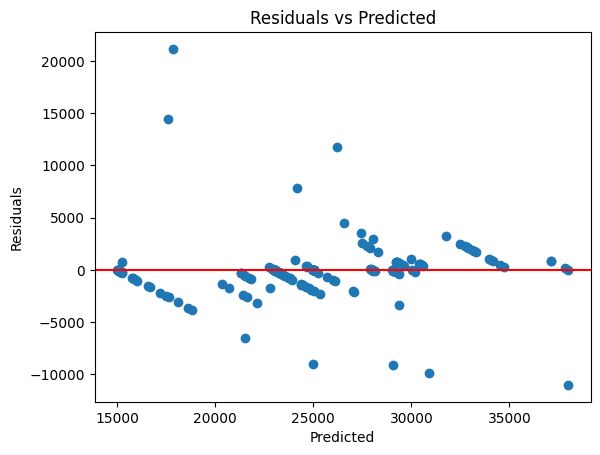

In [47]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_rf

plt.scatter(y_pred_rf, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

# Distribution of Residuals

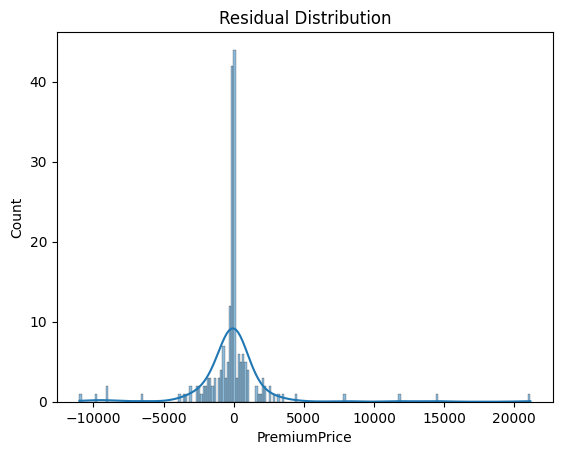

In [48]:
import seaborn as sns

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

#Residual diagnostics indicate that while the model captures overall patterns effectively, there is evidence of heteroskedasticity with increasing variance at higher predicted premium levels. Additionally, the presence of outliers suggests that the model struggles with extreme cases, indicating scope for further improvement through advanced models or feature engineering.

# Running three models to quickly compare which will perform better and why

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [50]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return r2, rmse

In [51]:
results = {}

results['Linear Regression'] = evaluate_model(lr, X_train_processed, X_test_processed, y_train, y_test)
results['Random Forest'] = evaluate_model(rf, X_train_processed, X_test_processed, y_train, y_test)
results['Gradient Boosting'] = evaluate_model(gbr, X_train_processed, X_test_processed, y_train, y_test)

results

{'Linear Regression': (0.5943285277951553, np.float64(3884.9069420472133)),
 'Random Forest': (0.7831675514759382, np.float64(2840.24316388387)),
 'Gradient Boosting': (0.7608882051976558, np.float64(2982.592255777489))}

# Tuning Gradient Boosting to check if the model performs better

In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

lr = LinearRegression()

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

In [53]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return r2, rmse

In [54]:
results = {}

results['Linear Regression'] = evaluate_model(lr, X_train_processed, X_test_processed, y_train, y_test)
results['Random Forest'] = evaluate_model(rf, X_train_processed, X_test_processed, y_train, y_test)
results['Gradient Boosting'] = evaluate_model(gbr, X_train_processed, X_test_processed, y_train, y_test)

results

{'Linear Regression': (0.5943285277951553, np.float64(3884.9069420472133)),
 'Random Forest': (0.7831675514759382, np.float64(2840.24316388387)),
 'Gradient Boosting': (0.7557575973960806, np.float64(3014.4210784879674))}

Multiple models were evaluated including Linear Regression, Random Forest, and Gradient Boosting.
Linear Regression underperformed due to its inability to capture non-linear relationships.
Random Forest achieved the best performance with the highest R² and lowest RMSE, making it the most suitable model for this dataset.
Gradient Boosting was also tested and tuned, but did not outperform Random Forest, likely due to dataset size and sensitivity to hyperparameters.



Random Forest performed better likely because it handles variance better and is less sensitive to hyperparameter tuning compared to Gradient Boosting, especially on moderately sized datasets.


In [55]:
# Train final model (not inside evaluate function)
rf.fit(X_train_processed, y_train)

# Save model + column schema
import joblib

joblib.dump(rf, "insurance_rf_model.pkl")
joblib.dump(X_train_processed.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [56]:
from google.colab import files

files.download("insurance_rf_model.pkl")
files.download("model_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
print(X_train_processed.columns.tolist())

['Age', 'Diabetes', 'BloodPressureProblems', 'AnyTransplants', 'AnyChronicDiseases', 'Height', 'Weight', 'KnownAllergies', 'HistoryOfCancerInFamily', 'NumberOfMajorSurgeries', 'Clean BMI Formula', 'Health Score', 'Age_Surgery', 'BMI_Health', 'BMI Categories_Obese', 'BMI Categories_Overweight', 'BMI Categories_Underweight', 'Risk Category_Low Risk', 'Risk Category_Medium Risk', 'Surgery_Bucket_1', 'Surgery_Bucket_2+']


In [58]:
import joblib
import pandas as pd

categorical_cols = ['BMI Categories', 'Risk Category', 'Surgery_Bucket']

X_processed = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

rf.fit(X_processed, y)

joblib.dump(rf, "insurance_rf_model.pkl")
joblib.dump(X_processed.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']

In [59]:
from google.colab import files
files.download("insurance_rf_model.pkl")
files.download("model_columns.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>